###  Example of the coherence computation


In this notebook we use the autoregressive example model from [Dhamala et. al.](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.100.018701). The model consists of two coupled random variables ($2\\rightarrow 1$), the coupling is time-varying therefore the coherence should detect the coupling dynamics. The model is given by the equations bellow:


$X_{1}(t) = 0.55X_{1}(t-1)-0.8X_{1}(t-2)+C(t)X_{2}(t-1)+\epsilon (t)$

$X_{2}(t) = 0.55X_{2}(t-1)-0.8X_{2}(t-2)+\xi (t)$

Here, $X_1(t)$ and $X_2(t)$ are $AR(2)$. The variable $t$ is the time step index,
such that the actual time is $t'=t\,\Delta t=t/f_{\\rm s}$. Besides, we know by construction that
$X_2(t)$ influences $X_1(t)$ through the coupling constant $C$
(although the opposite does not happen). In the simulation $C(t)=0.25$ for $t<15$ s, and zero otherwise.

In [79]:
import os

import jax
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from hoi.core import get_entropy, get_mi
from mne.time_frequency import psd_array_multitaper
from tqdm import tqdm

In [3]:
def ar_model_dhamala(
    N=5000, Trials=10, Fs=200, C=0.2, t_start=0, t_stop=None, cov=None
):
    """
    AR model from Dhamala et. al.
    """

    T = N / Fs

    time = np.linspace(0, T, N)

    X = np.random.random([Trials, N])
    Y = np.random.random([Trials, N])

    def interval(t, t_start, t_stop):
        if t_stop == None:
            return t >= t_start
        else:
            return (t >= t_start) * (t <= t_stop)

    for i in tqdm(range(Trials)):
        E = np.random.multivariate_normal(np.zeros(cov.shape[0]), cov, size=(N,))
        for t in range(2, N):
            X[i, t] = (
                0.55 * X[i, t - 1]
                - 0.8 * X[i, t - 2]
                + interval(time[t], t_start, t_stop) * C * Y[i, t - 1]
                + E[t, 0]
            )
            Y[i, t] = 0.55 * Y[i, t - 1] - 0.8 * Y[i, t - 2] + E[t, 1]

    Z = np.zeros([Trials, 2, N])

    Z[:, 0, :] = X
    Z[:, 1, :] = Y

    return Z

In [92]:
N = 5000  # Number of observations
Fs = 200  # Sampling frequency
dt = 1.0 / Fs  # Time resolution
C = 0.25  # Coupling parameter
Trials = 1_000  # Number of trials
freqs = np.arange(1, 100, 1)  # Frequency axis
# Covariance matrix
cov = np.array([[1.00, 0.00], [0.00, 1.00]])

In [93]:
# Generating data
X = ar_model_dhamala(N=N, Trials=Trials, C=C, Fs=Fs, t_start=0, t_stop=np.inf, cov=cov)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:07<00:00, 126.09it/s]


In [96]:
X = xr.DataArray(
    X,
    dims=("trials", "roi", "times"),
    coords=(np.arange(Trials), ["r0", "r1"], np.arange(N) / Fs),
)

X.attrs["fsample"] = Fs

In [97]:
freqs = np.linspace(0.1, 80, 50)

W, freqs = psd_array_multitaper(
    X,
    Fs,
    0,
    80
)

    Using multitaper spectrum estimation with 7 DPSS windows


In [98]:
W.shape

(1000, 2, 2001)

In [99]:
mi_fcn = get_mi("gc")

mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))

#### Mutual Information

In [100]:
MI_PHI = mi_fcn_time(W[:, 0][None], W[:, 1][None], False, True)

Text(0.5, 0, 'Time [s]')

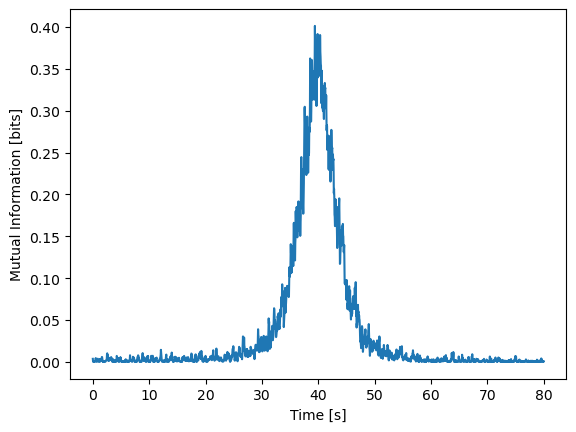

In [101]:
plt.plot(
    freqs, 
    MI_PHI
)

plt.ylabel("Mutual Information [bits]")
plt.xlabel("Time [s]")

#### Granger Causality (lag one)

In [106]:
mi_fcn = get_entropy("gc")

mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, None, None))

In [107]:
X2_past = W[:, 1,  :-1]  # X
X1_future = W[:, 0,  1:]  # Y
X1_past = W[:, 0, :-1]  # Z

mv = np.stack((X2_past, X1_future))

In [109]:
TE = (
    mi_fcn_time(np.stack((X2_past, X1_past)), False, True) +
    mi_fcn_time(np.stack((X1_future, X1_past)), False, True) - 
    mi_fcn_time(np.stack((X2_past, X1_future, X1_past)), False, True) - 
    mi_fcn_time(X1_past[None], False, True)  
)

ValueError: x and y must have same first dimension, but have shapes (2001,) and (2000,)

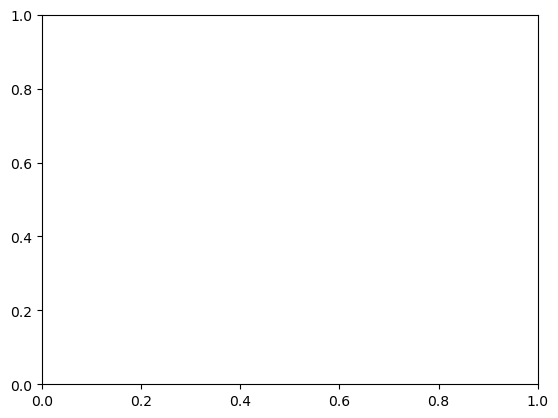

In [111]:
plt.imshow(TE, aspect="auto", cmap="turbo", extent=[0, 5, freqs[0], freqs[-1]], origin="lower")
plt.colorbar()
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")